# Medical Costs Analysis


This analysis explores the factors that influence healthcare expenses using a medical insurance dataset. The goal is to understand how patient characteristics such as age, BMI, and number of children affect medical charges.

Key questions:

How do medical costs vary with age?

Does BMI influence healthcare expenses?

Are families with more children associated with higher healthcare costs?

Can medical charges be predicted using these variables?

In [2]:
#importing the libraries
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
sns.set_style("whitegrid")

In [3]:
#loading the dataset 
df = pd.read_csv("insurance.csv")

In [4]:
#an overview of the dataset 
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Text(0.5, 1.0, 'Distribution of Medical Charges')

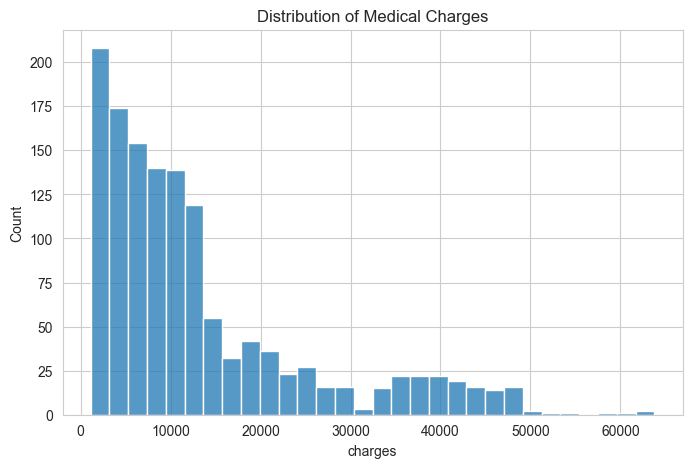

In [6]:
#distribution of heathcare costs 
plt.figure(figsize=(8,5))
sns.histplot(df["charges"], bins=30)
plt.title("Distribution of Medical Charges")

Analysis : Costs are right-skewed, meaning a small number of patients have extremely high expenses.

Text(0.5, 1.0, 'Age Distribution')

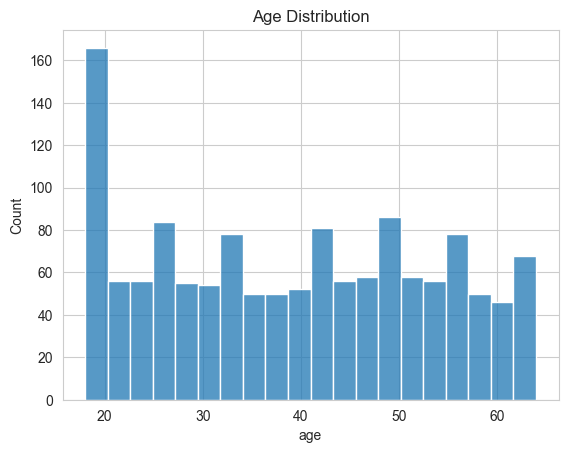

In [8]:
#distribution of age 
sns.histplot(df["age"], bins=20)
plt.title("Age Distribution")

Text(0.5, 1.0, 'BMI Distribution')

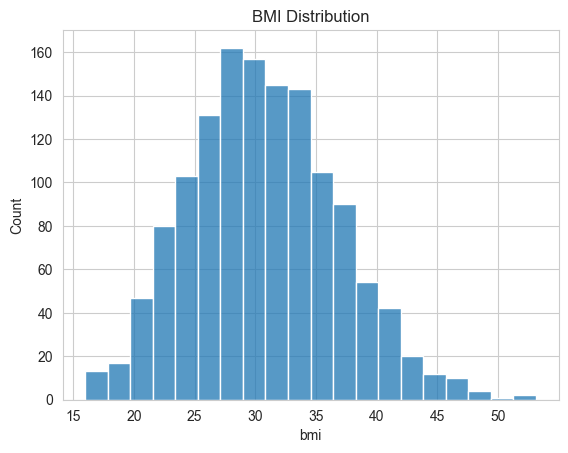

In [9]:
#distribution of bmi 
sns.histplot(df["bmi"], bins=20)
plt.title("BMI Distribution")

Text(0.5, 1.0, 'Age vs Medical Charges')

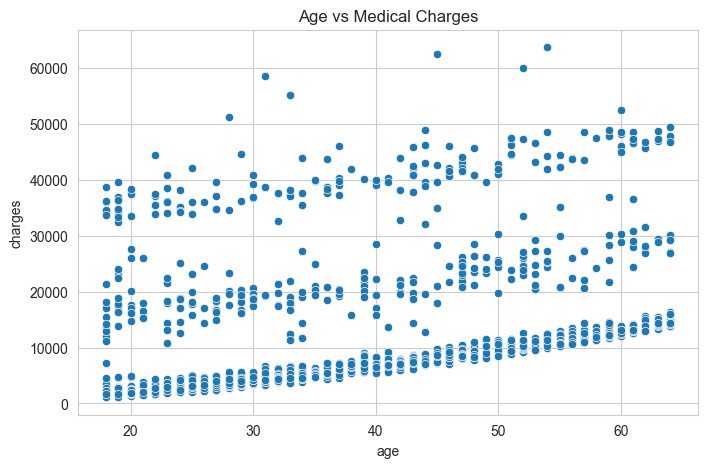

In [10]:
#age vs medical charges 
plt.figure(figsize=(8,5))
sns.scatterplot(x="age", y="charges", data=df)
plt.title("Age vs Medical Charges")

Text(0.5, 1.0, 'BMI vs Medical Charges')

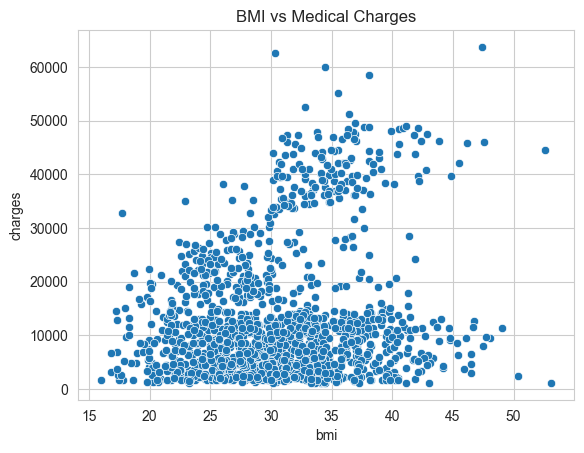

In [12]:
#bmi vs medical charges 
sns.scatterplot(x="bmi", y="charges", data=df)
plt.title("BMI vs Medical Charges")

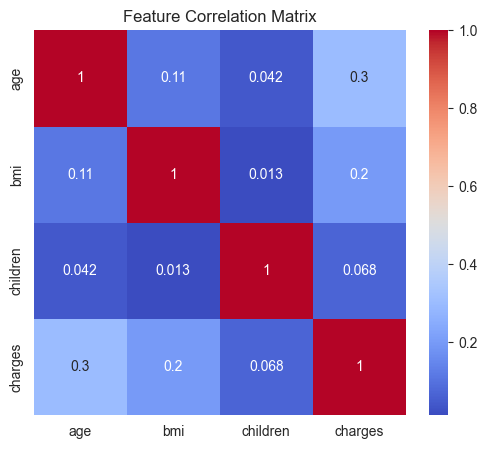

In [15]:
#correlation heatmap 
plt.figure(figsize=(6,5))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [16]:
#linear regression model 
#features 
X = df[["age","bmi","children"]]
y = df["charges"]

In [17]:
#training the model 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)

preds = model.predict(X_test)

r2_score(y_test,preds)

0.15489592484270753

In [19]:
#model coefficients 
pd.DataFrame({
"Feature":X.columns,
"Coefficient":model.coef_
})

,Feature,Coefficient
0,age,220.757765
1,bmi,332.202476
2,children,563.019432


Text(0.5, 1.0, 'Actual vs Predicted Medical Costs')

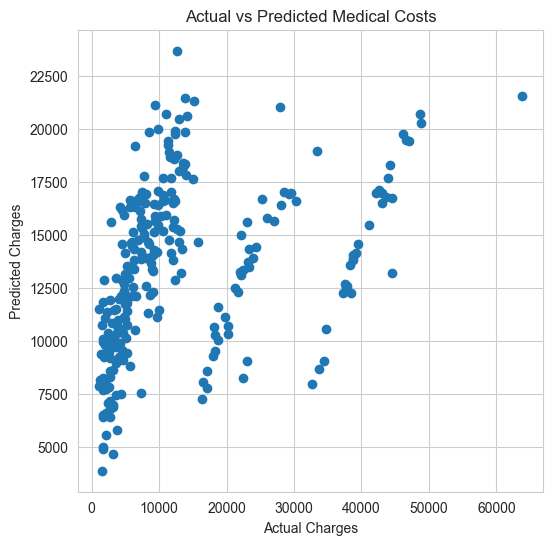

In [20]:
#actual vs predicted costs 
plt.figure(figsize=(6,6))
plt.scatter(y_test,preds)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Medical Costs")